# Which US Counties and States lack access to public airports?


Access to airports can boost connectivity and as a result, increase tourism and enhance regional visibility. This helps with the economic development and business activity of the surrounding regions. It is also critical to have ease of access to airports to support emergency services and disaster response in times of need, especially for regions with significant population density. 

In this example, we will use the Spatially Enabled DataFrame (SEDF) from the ArcGIS API for Python along with some spatial analysis concepts and techniques to answer some real-world questions. We will work through an example that seeks to answer the following questions:

> 1. Which counties contain airports?
> 2. Which counties *do not* contain airports?
> 3. Which of those counties do not have access to airports within 30 miles?

### Import necessary packages

In [24]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from arcgis.features import FeatureLayer, GeoAccessor
from arcgis.gis import GIS
from arcgis.geometry import Geometry, distance
from arcgis.geometry.functions import LengthUnits

In [ ]:
gis = GIS(profile="your_online_profile")

Having imported necessary packages and connecting to our GIS, we now proceed to read in the data required.

### Extract data for Counties of the US as a SEDF


We will access the data for Counties in the US and read it in as a Spatially Enabled DataFrame using the `spatial` namespace which returns a [__`GeoAccessor`__](https://developers.arcgis.com/python/latest/api-reference/arcgis.features.toc.html#geoaccessor) object.

In [3]:
counties_url = 'https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/services/USA_Counties_Generalized_Boundaries/FeatureServer/0'
counties_layer = FeatureLayer(counties_url)
counties_sdf = counties_layer.query(as_df=True, out_sr=4326)
counties_sdf.shape

(3144, 13)

This dataset has information for 3144 counties across the US. 

In [4]:
counties_sdf.head()

,OBJECTID,NAME,STATE_NAME,STATE_FIPS,FIPS,SQMI,POPULATION,POP_SQMI,STATE_ABBR,COUNTY_FIPS,Shape__Area,Shape__Length,SHAPE
0,2,Grant County,North Dakota,38,38037,1643.571429,2301,1.4,ND,037,0.504068,3.413506,"{""rings"": [[[-102.003385812939, 46.05284759773..."
1,3,Griggs County,North Dakota,38,38039,720.625,2306,3.2,ND,039,0.223034,1.949037,"{""rings"": [[[-97.9616729885937, 47.24493801330..."
2,4,Hettinger County,North Dakota,38,38041,1131.363636,2489,2.2,ND,041,0.342747,2.691898,"{""rings"": [[[-102.003371825849, 46.20580311678..."
3,5,Kidder County,North Dakota,38,38043,1408.235294,2394,1.7,ND,043,0.437806,2.719487,"{""rings"": [[[-100.088490419176, 46.63570178753..."
4,7,Logan County,North Dakota,38,38047,987.368421,1876,1.9,ND,047,0.309011,2.454735,"{""rings"": [[[-99.0440801101036, 46.28338272232..."


### Extract Spatially Enabled DataFrames for Airports across the US

The data for airports in the US is available across 3 different layers based on the scale of the airport.

1. The first layer, extracted as SEDF `airports1`, comprises of airports with capacity of 1,000,000 or more.
2. The second layer, extracted as SEDF `airports2`, comprises of airports with capacity of 100,000 - 999,999.
3. The third layer, extracted as SEDF `airports3`, comprises of airports with capacity of less than 100,000.

Once we extract data for all 3 SEDFs, we then combine them to create `airports` that we will use going forward. 

In [5]:
airports1_url = 'https://services.arcgis.com/P3ePLMYs2RVChkJx/ArcGIS/rest/services/USA_Airports_by_scale/FeatureServer/1'
airports1 = FeatureLayer(airports1_url).query(as_df=True, out_sr=4326)

airports2_url = 'https://services.arcgis.com/P3ePLMYs2RVChkJx/ArcGIS/rest/services/USA_Airports_by_scale/FeatureServer/2'
airports2 = FeatureLayer(airports2_url).query(as_df=True, out_sr=4326)

airports3_url = 'https://services.arcgis.com/P3ePLMYs2RVChkJx/ArcGIS/rest/services/USA_Airports_by_scale/FeatureServer/3'
airports3 = FeatureLayer(airports3_url).query(as_df=True, out_sr=4326)

airports = pd.concat([airports1, airports2, airports3], ignore_index=True, sort=False)
airports.head()

,OBJECTID,FAA_ID,NAME,FACILITY,CITY,COUNTY,STATE,OWNER,ELEV_FEET,INTL,TOWER,ARRIVALS,DEPARTURES,ENPLANEMEN,PASSENGERS,SHAPE
0,29,ANC,Ted Stevens Anchorage Intl,Airport,Anchorage,Anchorage,AK,Public,151,N,Y,18519.0,18524.0,2291115.0,1970743.0,"{""x"": -149.9981944442182, ""y"": 61.174083333778..."
1,761,BHM,Birmingham-Shuttlesworth Intl,Airport,Birmingham,Jefferson,AL,Public,650,N,Y,16741.0,16738.0,1332942.0,1205588.0,"{""x"": -86.75230555515719, ""y"": 33.563888889160..."
2,1179,LIT,Bill And Hillary Clinton National/Adams Field,Airport,Little Rock,Pulaski,AR,Public,266,N,Y,15475.0,15472.0,1054815.0,955228.0,"{""x"": -92.22477777747241, ""y"": 34.729444444105..."
3,1503,PHX,Phoenix Sky Harbor Intl,Airport,Phoenix,Maricopa,AZ,Public,1135,N,Y,177027.0,177030.0,19156669.0,15944437.0,"{""x"": -112.01158333360394, ""y"": 33.43427777749..."
4,1593,TUS,Tucson Intl,Airport,Tucson,Pima,AZ,Public,2643,Y,Y,19494.0,19494.0,1569388.0,1315515.0,"{""x"": -110.94102777810946, ""y"": 32.11608333317..."


### Restrict the airports to 'Public' airports


If we observe values of the `OWNER` attribute of the `airports` data below, we notice that some of the airports are privately owned and some are dedicated for military use. We want to limit our `airports` data to include only `public_airports` that can be accessed by the general public.

In [6]:
airports['OWNER'].value_counts()

OWNER
Public       772
Air Force     50
Private       24
Navy          14
Army          13
Name: count, dtype: Int64

In [7]:
public_airports = airports[airports['OWNER']=='Public']

In [39]:
public_airports.shape

(772, 16)

As we see above, the US has 772 airports accessible to the public.

### __1. Which counties have public airports within?__


This leads us to the first of our 3 questions: Which counties have public airports within? 

We spatially join the public airports with the counties to see which airports intersect counties and visualize the results on a map. 

In [8]:
spatially_joined = public_airports.spatial.join(counties_sdf, how='left', op='intersects')

In [9]:
counties_with_airports = counties_sdf[counties_sdf['COUNTY_FIPS'].isin(list((spatially_joined['COUNTY_FIPS']).unique()))]
counties_with_airports.shape

(2781, 13)

This gives us 2781 counties (of the 3144 total counties) which have airports within.  This shows us that most counties have public airports within, however there are a few missing gaps in the south, central part of the country, Midwest and south east that indicate counties without airports.


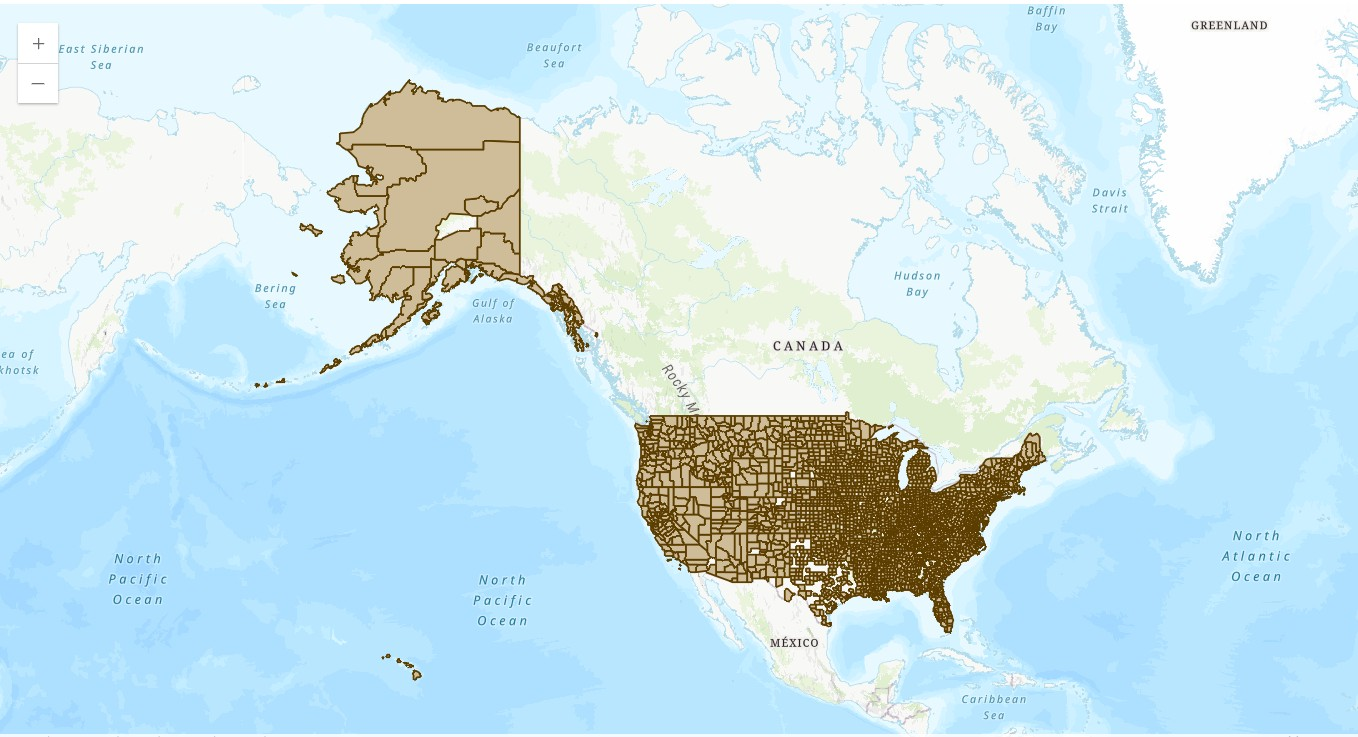

In [34]:
map1 = gis.map('USA')
counties_with_airports.spatial.plot(map1)
map1.zoom_to_layer(counties_with_airports)
map1

We can also print out the names of states that are served by airports in their counties.

In [12]:
print(counties_with_airports['STATE_NAME'].unique())

<StringArray>
[        'North Dakota',             'Oklahoma',               'Oregon',
         'South Dakota',               'Hawaii',                'Idaho',
               'Kansas',               'Alaska',           'California',
             'Colorado',              'Georgia',             'Missouri',
              'Montana',             'Nebraska',               'Nevada',
           'New Mexico',             'Kentucky',             'Michigan',
          'Mississippi',              'Wyoming',          'Connecticut',
                'Texas',                 'Utah',             'Virginia',
           'Washington',                 'Ohio',         'Pennsylvania',
       'South Carolina',            'Tennessee',             'Illinois',
              'Indiana',                 'Iowa',              'Alabama',
             'Arkansas',              'Florida',       'North Carolina',
            'Louisiana',                'Maine',        'Massachusetts',
            'Minnesota',        'West

## __2. Which counties are underserved by access to airports, despite average or greater population density?__


This leads us to find which of these missing counties do not have access to airports despite average or greater population density? 

For this we use the `enrich_layer` analysis method to enrich the counties with data for population for each of these counties from the most recent year (2025) using the `TOTPOP_CY` variable.

### Enrich counties with population data from 2025

In [13]:
from arcgis.features.analysis import enrich_layer

<Item title:"enriched_counties_2025" type:Feature Layer Collection owner:MMajumdar_geosaurus>
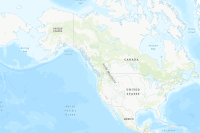

In [15]:
enriched_counties = enrich_layer(counties_layer, analysis_variables=['TOTPOP_CY'], output_name='enriched_counties_2025')
enriched_counties

In [16]:
enriched_df = FeatureLayer(enriched_counties.url+'/0').query(as_df=True, out_sr=4326)

### Calculating population density for each county


We now calculate the population density for each of these counties using the population data and the area (`SQMI` field), and the median population density for the entire country.

In [17]:
enriched_df['pop_density'] = enriched_df['TOTPOP_CY'] / enriched_df['SQMI']
enriched_df['pop_density'].head()

0    51.558841
1     1.324555
2     3.073721
3     2.113379
4     1.638931
Name: pop_density, dtype: Float64

### Calculating median population density

In [18]:
median_pop_density = enriched_df['pop_density'].median()
float(median_pop_density)

44.903376023126796

### Finding counties that DO NOT have airports and have average or greater population density


We use this to to write a query below to find which of the counties that lack airports also have population density greater than or equal to the median. This leaves us with 163 counties, aligning with what we saw in the missing gaps of the previous map.

In [19]:
counties_without_airports = enriched_df[~enriched_df['COUNTY_FIPS'].isin(list((spatially_joined['COUNTY_FIPS']).unique())) & (enriched_df['pop_density']>=median_pop_density)]
counties_without_airports.shape

(163, 20)


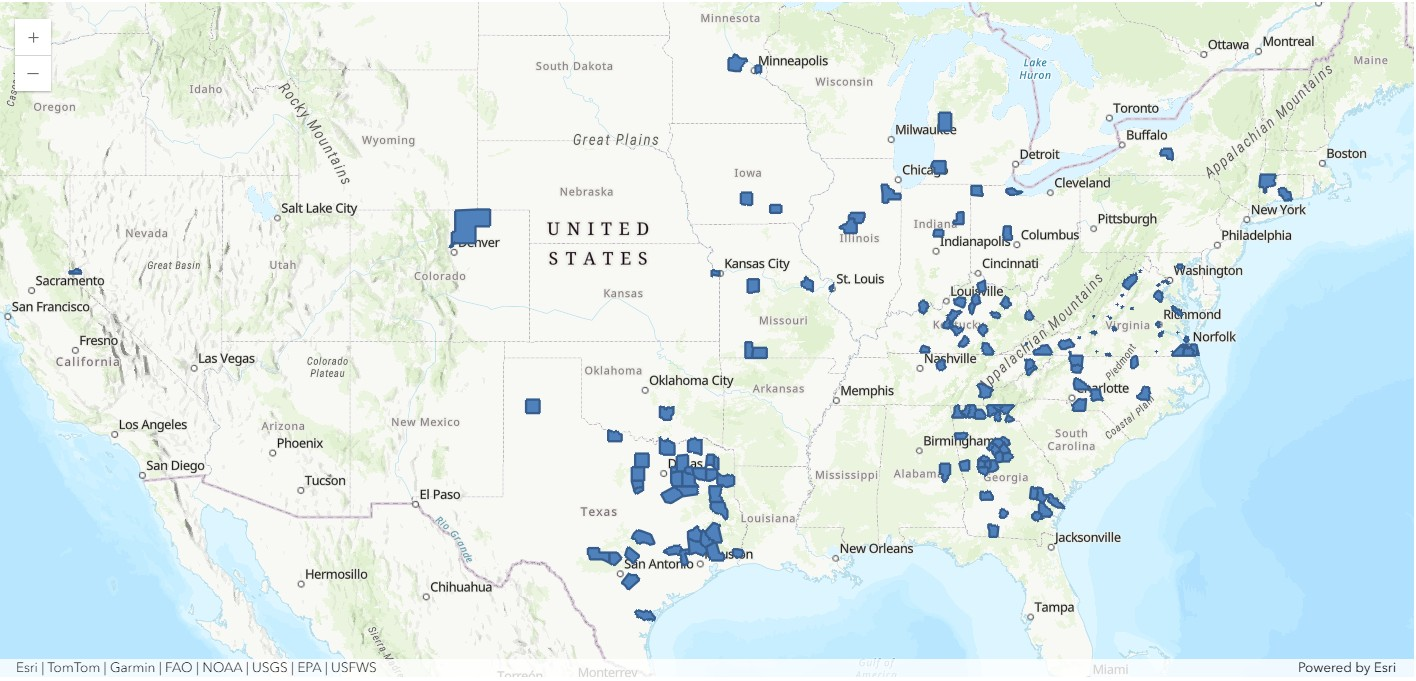

In [37]:
map2 = gis.map('USA')
counties_without_airports.spatial.plot(map2)
map2.zoom_to_layer(counties_without_airports)
map2

We also print out the names of states that lack have counties lacking airports. 

In [21]:
print(counties_without_airports['STATE_NAME'].unique())

<StringArray>
[          'Ohio',       'Oklahoma',        'Alabama',       'Colorado',
        'Georgia',       'Missouri',         'Nevada',       'New York',
 'North Carolina',       'Kentucky',       'Maryland',       'Michigan',
      'Minnesota',      'Tennessee',    'Connecticut',          'Texas',
       'Virginia',           'Iowa',         'Kansas',       'Illinois',
        'Indiana']
Length: 21, dtype: string


### __3. Which counties are underserved by access to airports within 30 miles?__


However, if these counties do not have airports, are they at least within 30 miles of one? To determine this, we first calculate centroids for our counties and then compute a spatial index for each public airport.


In [22]:
#Generate centroids for counties
def get_x(value):
    '''
    Extract x co-ordinate from the centroid column
    '''
    return value[0]

def get_y(value):
    '''
    Extract y co-ordinate from the centroid column
    '''
    return value[1]

counties_without_airports['centroid'] = counties_without_airports['SHAPE'].geom.centroid
counties_without_airports['centroid_x'] = counties_without_airports['centroid'].apply(get_x)
counties_without_airports['centroid_y'] = counties_without_airports['centroid'].apply(get_y)

A [spatial index](https://developers.arcgis.com/python/latest/api-reference/arcgis.features.toc.html#arcgis.features.GeoAccessor.sindex) can be thought of as an index on the `SHAPE` column. This can be used to quickly locate and search for features and also perform many selection or identification tasks. 


In [23]:
#Generate spatial index for airports
sindex_airports = public_airports.spatial.sindex(stype='rtree')

We now write this method below to loop through each county and find its nearest airport using the spatial index for a quick search. We then use the __[`distance()`](https://developers.arcgis.com/python/latest/api-reference/arcgis.geometry.functions.html#distance)__ geometry method to find the distance between the centroid of the county and the closest airport in miles. We extract this data in the form of a distance matrix that gives us the distance between a county and its nearest airport, along with the population density. 

In [25]:
counties_without_airport_access = []
for row in counties_without_airports[['centroid_x', 'centroid_y', 'SHAPE', 'pop_density']].to_records():
    row = list(row)
    g = row[3]
    source_idx = row[0]
    latlong = (row[1], row[2])
    #Finding nearest airport to each county
    r = [i for i in sindex_airports._index.nearest(latlong, num_results=1)]
    r = list(set(r))
    centroid = Geometry({"x": row[1], "y":row[2], "spatialReference":{'wkid':4326}})
    #Find distance between county and closest airport
    dists = [distance(spatial_ref='4326', geometry1 = centroid, geometry2=public_airports['SHAPE'][i], distance_unit=LengthUnits.SURVEYMILE, geodesic=True) for i in r]
    row = row + r + dists
    counties_without_airport_access.append(row)

In [26]:
df_dist_matrix = pd.DataFrame(data=counties_without_airport_access, columns=['county_idx', 'centroid_x', 'centroid_y', 
                                                                'SHAPE', 'pop_density', 'airport_idx','dist'])
df_dist_matrix.head()

,county_idx,centroid_x,centroid_y,SHAPE,pop_density,airport_idx,dist
0,97,-83.165717,41.532653,"{'rings': [[[-83.408963087, 41.497789379], [-8...",121.039060,739,{'distance': 33.49273640493922}
1,115,-83.367804,40.297096,"{'rings': [[[-83.499565192, 40.1136267840001],...",164.269443,61,{'distance': 32.60488307378162}
2,121,-84.576047,41.561072,"{'rings': [[[-84.791897201, 41.4278994090001],...",86.147014,739,{'distance': 39.85057292486108}
3,185,-96.678372,34.735751,"{'rings': [[[-96.824187087, 34.515547381], [-9...",53.253054,63,{'distance': 69.18399832721137}
4,268,-85.796065,32.869278,"{'rings': [[[-85.589628589, 32.7313466890001],...",52.713994,414,{'distance': 39.07221261130234}


In [27]:
def get_distance(x):
    '''
    Fetch distance value from the distance disctionary
    '''
    return x['distance']

df_dist_matrix['distance'] = df_dist_matrix['dist'].apply(get_distance)

In [28]:
df_dist_matrix_filter = df_dist_matrix[(df_dist_matrix['pop_density'] >= median_pop_density) & (df_dist_matrix['distance'] > 30)]
df_dist_matrix_filter.shape

(77, 8)

We now find which of the previous 163 counties also has their closest airport more than 30 miles away. This leaves us with 77 airports.

We now retrieve the `SHAPE` for these counties from our previous SEDF to then visualize the results on a map.

In [29]:
counties_away_from_airports = counties_without_airports[counties_without_airports['SHAPE'].isin(list((df_dist_matrix_filter['SHAPE']).unique()))]
counties_away_from_airports.shape

(77, 23)

The map below shows us that a few airports we saw initially in the Midwest and the central part of the country are no longer on this map, indicating that they are within 30 miles of the closest airport.


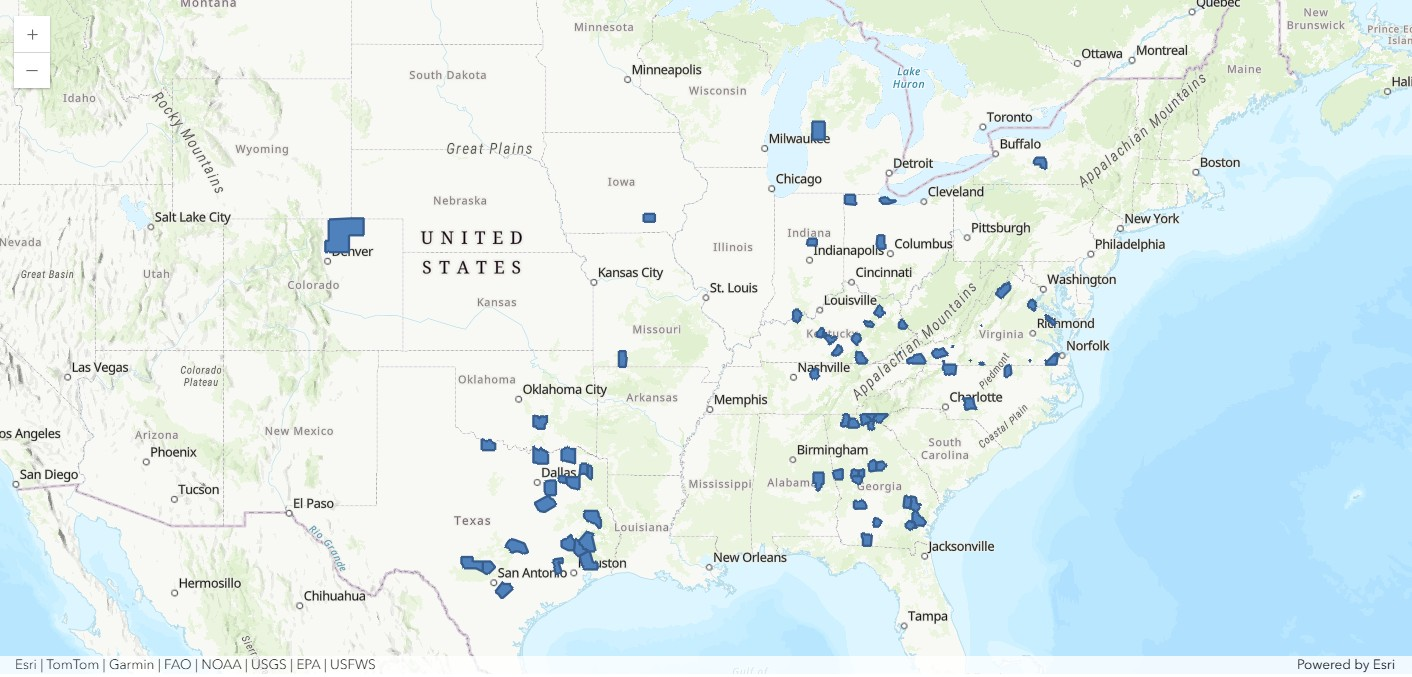

In [38]:
map3 = gis.map('USA')
counties_away_from_airports.spatial.plot(map3)
map3.zoom_to_layer(counties_away_from_airports)
map3

We can also see state names for these counties. __The following list of states can be used to plan efforts which advocate for policy changes that benefit the underserved communities with access to airports through future infrastructure development.__

In [34]:
counties_away_from_airports['STATE_NAME'].unique()

array(['Alabama', 'Colorado', 'Georgia', 'Indiana', 'Iowa', 'Kentucky',
       'Michigan', 'Mississippi', 'Missouri', 'New York',
       'North Carolina', 'Ohio', 'Oklahoma', 'Tennessee', 'Texas',
       'Virginia'], dtype=object)

This sample notebook shows us how simple tools can be used from the ArcGIS API for Python to explore and address some critical questions.